# Speech Emotion Recognition (SER) Final Ensemble Pipeline

This notebook implements the complete final training and evaluation pipeline for our **Optimally Weighted Ensemble** (combining **XGBoost**, **LightGBM**, and **CatBoost**). 

### Key Features:
1. **Full Feature Set**: Dynamically loads and utilizes all **48 features** from the dataset.
2. **Out-of-Fold (OOF) Weight Optimization**: Uses a 3-Fold Stratified Cross-Validation on the training set to optimize the soft-voting weights for blending the three classifiers.
3. **GPU/CPU Automatic Detection**: Auto-detects CUDA/GPU availability to run calculations efficiently.
4. **Rich Visualizations**: Generates confusion matrices, model comparison plots, and per-class performance breakdowns.


In [1]:
# ============================================================
# Library Imports
# ============================================================
import json
import os
import warnings
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import xgboost as xgb
except ImportError:
    %pip install xgboost -q
    import xgboost as xgb

try:
    import lightgbm as lgb
except ImportError:
    %pip install lightgbm -q
    import lightgbm as lgb

try:
    from catboost import CatBoostClassifier
except ImportError:
    %pip install catboost -q
    from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch

warnings.filterwarnings("ignore")


In [2]:
# ============================================================
# Global Constants & GPU Support Check
# ============================================================
RANDOM_STATE = 42

# Check if CUDA/GPU support is available
CUDA_AVAILABLE = torch.cuda.is_available()
print("CUDA Available (PyTorch):", CUDA_AVAILABLE)


CUDA Available (PyTorch): False


## Dataset Path Configuration

We resolve the location of the `all_emotions.csv` dataset, using a robust path fallback that checks both the `dataset/` subdirectory and the repository root.


In [3]:
# ============================================================
# Path Configuration
# ============================================================
_base = os.getcwd()
_project_root = os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
ALL_EMOTIONS_CSV = os.path.normpath(os.path.join(_project_root, "dataset", "all_emotions.csv"))
if not os.path.isfile(ALL_EMOTIONS_CSV):
    fallback_csv = os.path.normpath(os.path.join(_project_root, "all_emotions.csv"))
    if os.path.isfile(fallback_csv):
        ALL_EMOTIONS_CSV = fallback_csv

print("Dataset path:", ALL_EMOTIONS_CSV)
print("File exists:", os.path.isfile(ALL_EMOTIONS_CSV))


Dataset path: c:\Users\User\Downloads\Saggin-Computational-Architectures-in-Speech-Emotion-Recognition-main\Saggin-Computational-Architectures-in-Speech-Emotion-Recognition-main\all_emotions.csv
File exists: True


## Data Loading, Imputation & Feature Extraction

We load the CSV file, clean null targets, and dynamically extract **all available feature columns** (excluding the target labels column). Missing values are handled using median imputation.


In [4]:
# ============================================================
# Data Loading and Exploration
# ============================================================
df = pd.read_csv(ALL_EMOTIONS_CSV)
target_col = "label" if "label" in df.columns else "Label"

# Clean missing label rows
df_cleaned = df.dropna(subset=[target_col]).copy()
df_cleaned = df_cleaned[df_cleaned[target_col].astype(str).str.strip().str.lower() != "nan"]

# Extract all columns except the target label as features (48 features)
FEATURE_COLS = [col for col in df_cleaned.columns if col not in [target_col]]
print(f"Number of features selected dynamically: {len(FEATURE_COLS)}")

# Feature Imputation
for col in FEATURE_COLS:
    s = pd.to_numeric(df_cleaned[col], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    df_cleaned[col] = s.fillna(med)

X = df_cleaned[FEATURE_COLS].values
y_label = df_cleaned[target_col].astype(str).str.strip().values

# Label encoding
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_label)

print(f"Cleaned X shape: {X.shape}")
print(f"Classes: {encoder.classes_}")


Number of features selected dynamically: 48
Cleaned X shape: (54485, 48)
Classes: ['anger' 'disgust' 'fear' 'happy' 'neutral' 'sad']


## Train-Test Splitting & Scaling

We split the dataset into stratified training (80%) and testing (20%) sets to ensure proportional label distribution, and perform standard scaling on feature matrices.


In [5]:
# ============================================================
# Stratified Train-Test Split and Standard Scaling
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train Shape: {X_train_scaled.shape} | Test Shape: {X_test_scaled.shape}")


Train Shape: (43588, 48) | Test Shape: (10897, 48)


## Model Instantiation with Best Hyperparameters

We load or define the optimized hyperparameters for XGBoost, LightGBM, and CatBoost. The model constructor dynamically configures GPU/CPU run options based on hardware availability.


In [6]:
# ============================================================
# Model Instantiation
# ============================================================
# Try to load best parameters if they exist, otherwise use optimized defaults
params_path = os.path.join(_project_root, "best_params.json")
best_params = {}
if os.path.isfile(params_path):
    try:
        with open(params_path, "r") as f:
            best_params = json.load(f)
        print("Loaded best_params.json successfully.")
    except Exception as e:
        print("Error loading best_params.json:", e)

xgb_params = best_params.get("xgboost", {
    "n_estimators": 468,
    "max_depth": 10,
    "learning_rate": 0.17549140891728818,
    "subsample": 0.9690394070981359,
    "colsample_bytree": 0.7725519831966194,
    "gamma": 1.0492767129301485e-08,
})
xgb_model = xgb.XGBClassifier(
    **xgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="mlogloss",
    objective="multi:softprob",
    num_class=len(encoder.classes_),
    device="cuda" if CUDA_AVAILABLE else "cpu",
)

lgb_params = best_params.get("lightgbm", {
    "n_estimators": 499,
    "max_depth": 11,
    "num_leaves": 67,
    "learning_rate": 0.24625126683753454,
    "subsample": 0.6909971314141472,
    "colsample_bytree": 0.7554088091076056,
})
lgb_model = lgb.LGBMClassifier(
    **lgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    objective="multiclass",
    num_class=len(encoder.classes_),
    device="gpu" if CUDA_AVAILABLE else "cpu",
)

cb_params = best_params.get("catboost", {
    "iterations": 500,
    "depth": 8,
    "learning_rate": 0.15,
    "l2_leaf_reg": 3.0,
})
cb_model = CatBoostClassifier(
    **cb_params,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=False,
    task_type="GPU" if CUDA_AVAILABLE else "CPU",
)

print("Models instantiated successfully.")


Loaded best_params.json successfully.
Models instantiated successfully.


## Out-of-Fold (OOF) Prediction Generation

To find the optimal blending weights without data leakage, we perform a 3-Fold Stratified Cross-Validation on the training set. We generate validation class probability predictions (out-of-fold predictions) for each model.


In [7]:
# ============================================================
# Out-of-Fold Predictions
# ============================================================
print("Training Out-Of-Fold models for weight optimization...")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
xgb_oof = np.zeros((len(X_train_scaled), len(encoder.classes_)))
lgb_oof = np.zeros((len(X_train_scaled), len(encoder.classes_)))
cb_oof = np.zeros((len(X_train_scaled), len(encoder.classes_)))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
    print(f"  Processing Fold {fold + 1}...")
    X_tr, y_tr = X_train_scaled[train_idx], y_train[train_idx]
    X_va, y_va = X_train_scaled[val_idx], y_train[val_idx]

    # Instantiate fold models
    xgb_m = xgb.XGBClassifier(
        **xgb_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="mlogloss",
        objective="multi:softprob",
        num_class=len(encoder.classes_),
        device="cuda" if CUDA_AVAILABLE else "cpu",
    )
    lgb_m = lgb.LGBMClassifier(
        **lgb_params,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        objective="multiclass",
        num_class=len(encoder.classes_),
        device="gpu" if CUDA_AVAILABLE else "cpu",
    )
    cb_m = CatBoostClassifier(
        **cb_params,
        loss_function="MultiClass",
        random_seed=RANDOM_STATE,
        thread_count=-1,
        verbose=False,
        task_type="GPU" if CUDA_AVAILABLE else "CPU",
    )

    # Fit and predict probabilities
    xgb_m.fit(X_tr, y_tr)
    lgb_m.fit(X_tr, y_tr)
    cb_m.fit(X_tr, y_tr)

    xgb_oof[val_idx] = xgb_m.predict_proba(X_va)
    lgb_oof[val_idx] = lgb_m.predict_proba(X_va)
    cb_oof[val_idx] = cb_m.predict_proba(X_va)

print("OOF predictions generated successfully.")


Training Out-Of-Fold models for weight optimization...
  Processing Fold 1...
  Processing Fold 2...
  Processing Fold 3...
OOF predictions generated successfully.


## Optimization of Blending Weights

We run a grid search over possible weight combinations (summing to 1) to find the weights that maximize the weighted F1-score on the out-of-fold validation predictions.


In [8]:
# ============================================================
# Ensemble Weight Optimization
# ============================================================
best_f1 = 0.0
best_weights = np.array([1.0, 1.0, 1.0]) / 3.0

# Grid search over possible weight combinations
for w_xgb in np.linspace(0, 1, 11):
    for w_lgb in np.linspace(0, 1 - w_xgb, 11):
        w_cb = 1.0 - w_xgb - w_lgb
        if w_cb < 0:
            continue
            
        weights = np.array([w_xgb, w_lgb, w_cb])
        val_proba = (
            w_xgb * xgb_oof +
            w_lgb * lgb_oof +
            w_cb * cb_oof
        )
        preds = np.argmax(val_proba, axis=1)
        score = f1_score(y_train, preds, average="weighted")
        
        if score > best_f1:
            best_f1 = score
            best_weights = weights

print(f"Optimized Blending Weights: XGBoost={best_weights[0]:.2f}, LightGBM={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"Best OOF Validation F1-Score: {best_f1:.4f}")


Optimized Blending Weights: XGBoost=0.40, LightGBM=0.42, CatBoost=0.18
Best OOF Validation F1-Score: 0.8478


## Final Model Training on Full Training Set

We fit the final XGBoost, LightGBM, and CatBoost models on the complete training scaled dataset, and extract class probability predictions on the unseen test set.


In [9]:
# ============================================================
# Final Training & Test Prediction
# ============================================================
print("Fitting final models on full scaled training set...")
xgb_model.fit(X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)
cb_model.fit(X_train_scaled, y_train)

# Generate test set predictions
xgb_pred = xgb_model.predict(X_test_scaled)
lgb_pred = lgb_model.predict(X_test_scaled)
cb_pred = cb_model.predict(X_test_scaled).flatten()

xgb_proba = xgb_model.predict_proba(X_test_scaled)
lgb_proba = lgb_model.predict_proba(X_test_scaled)
cb_proba = cb_model.predict_proba(X_test_scaled)

# Construct final weighted ensemble probabilities
ensemble_proba = (
    best_weights[0] * xgb_proba +
    best_weights[1] * lgb_proba +
    best_weights[2] * cb_proba
)
ensemble_pred = np.argmax(ensemble_proba, axis=1)

print("Final predictions computed.")


Fitting final models on full scaled training set...
Final predictions computed.


## Performance Evaluation: Classification Reports

We compute and compare individual model test metrics against the optimized ensemble test metrics.


In [10]:
# ============================================================
# Model Performance Evaluation
# ============================================================
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")
xgb_kappa = cohen_kappa_score(y_test, xgb_pred)

lgb_f1 = f1_score(y_test, lgb_pred, average="weighted")
lgb_kappa = cohen_kappa_score(y_test, lgb_pred)

cb_f1 = f1_score(y_test, cb_pred, average="weighted")
cb_kappa = cohen_kappa_score(y_test, cb_pred)

ensemble_f1 = f1_score(y_test, ensemble_pred, average="weighted")
ensemble_kappa = cohen_kappa_score(y_test, ensemble_pred)
ensemble_report = classification_report(y_test, ensemble_pred, target_names=encoder.classes_, output_dict=True)

print("\n=== XGBoost Test Metrics ===")
print(classification_report(y_test, xgb_pred, target_names=encoder.classes_))

print("\n=== LightGBM Test Metrics ===")
print(classification_report(y_test, lgb_pred, target_names=encoder.classes_))

print("\n=== CatBoost Test Metrics ===")
print(classification_report(y_test, cb_pred, target_names=encoder.classes_))

print("\n=== Optimally Weighted Ensemble (XGB + LGB + CB) ===")
print(classification_report(y_test, ensemble_pred, target_names=encoder.classes_))



=== XGBoost Test Metrics ===
              precision    recall  f1-score   support

       anger       0.94      0.91      0.93      1863
     disgust       0.84      0.87      0.86      1863
        fear       0.87      0.85      0.86      1863
       happy       0.83      0.86      0.85      1863
     neutral       0.80      0.83      0.81      1583
         sad       0.88      0.86      0.87      1862

    accuracy                           0.86     10897
   macro avg       0.86      0.86      0.86     10897
weighted avg       0.86      0.86      0.86     10897


=== LightGBM Test Metrics ===
              precision    recall  f1-score   support

       anger       0.95      0.91      0.93      1863
     disgust       0.85      0.88      0.86      1863
        fear       0.87      0.87      0.87      1863
       happy       0.85      0.86      0.86      1863
     neutral       0.81      0.84      0.82      1583
         sad       0.88      0.86      0.87      1862

    accuracy    

## Confusion Matrices Visualizations

We plot and display the confusion matrices for XGBoost, LightGBM, CatBoost, and the Weighted Ensemble side-by-side.


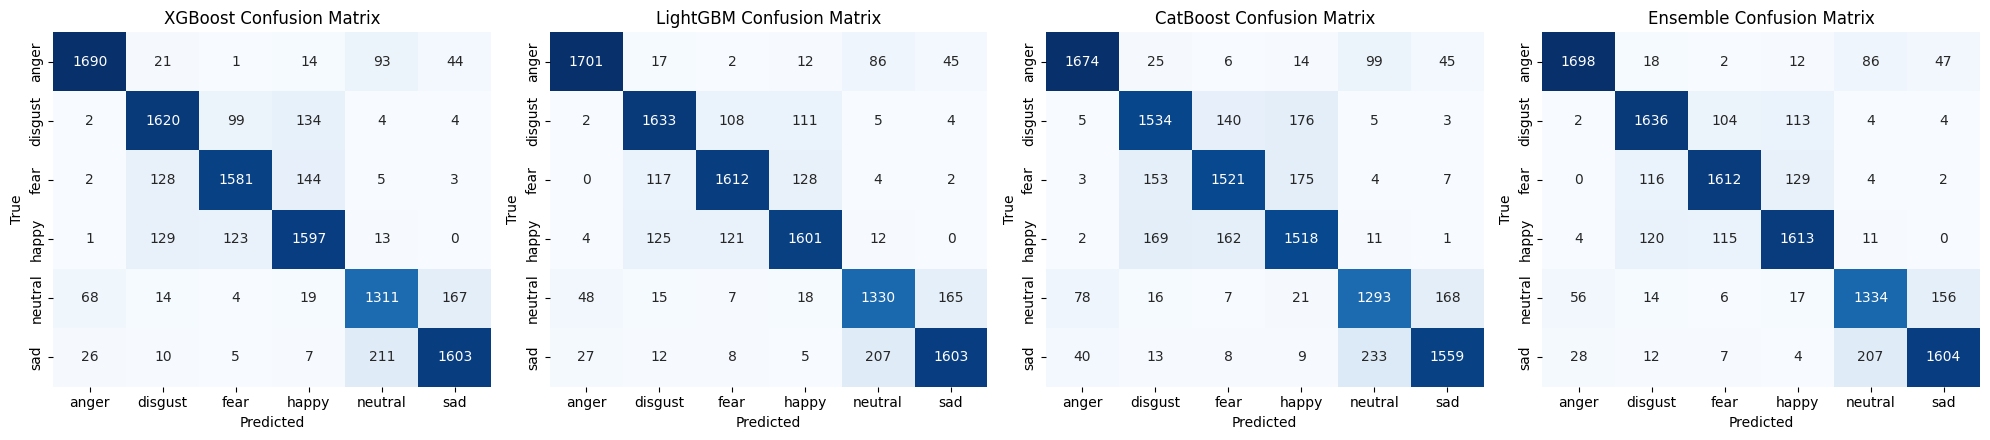

In [11]:
# ============================================================
# Visualizing Performance: Confusion Matrices
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, (pred, title) in enumerate([
    (xgb_pred, "XGBoost"),
    (lgb_pred, "LightGBM"),
    (cb_pred, "CatBoost"),
    (ensemble_pred, "Ensemble"),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False,
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    axes[idx].set_title(f"{title} Confusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")

plt.tight_layout()
plt.show()


## Overall Metric Comparisons (F1-Score and Cohen Kappa)


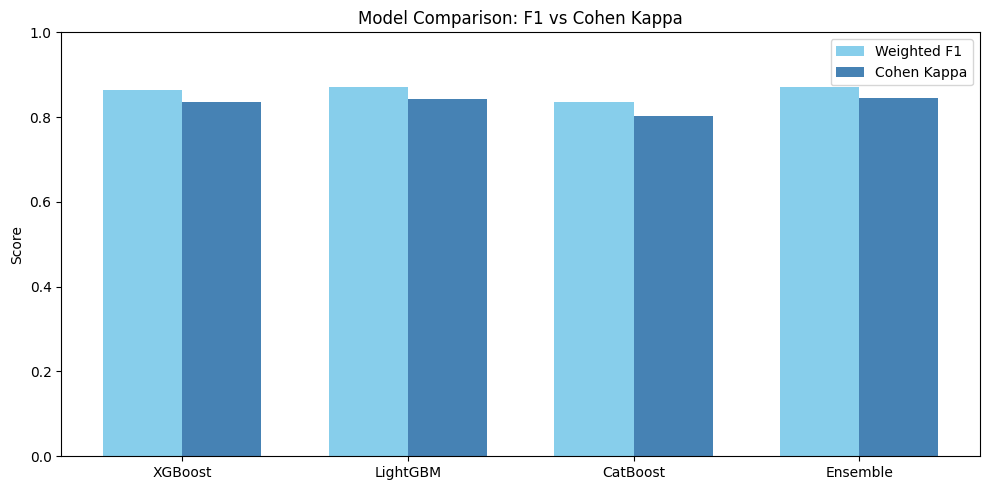

In [12]:
# ============================================================
# Model Comparison Plot (F1-Score vs Cohen Kappa)
# ============================================================
results = {
    "XGBoost": {"f1": xgb_f1, "kappa": xgb_kappa},
    "LightGBM": {"f1": lgb_f1, "kappa": lgb_kappa},
    "CatBoost": {"f1": cb_f1, "kappa": cb_kappa},
    "Ensemble": {"f1": ensemble_f1, "kappa": ensemble_kappa},
}

names = list(results.keys())
f1_scores = [results[name]["f1"] for name in names]
kappas = [results[name]["kappa"] for name in names]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, f1_scores, width, label="Weighted F1", color="skyblue")
plt.bar(x + width / 2, kappas, width, label="Cohen Kappa", color="steelblue")
plt.xticks(x, names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison: F1 vs Cohen Kappa")
plt.legend()
plt.tight_layout()
plt.show()


## Ensemble Per-Class F1-Scores Breakdown


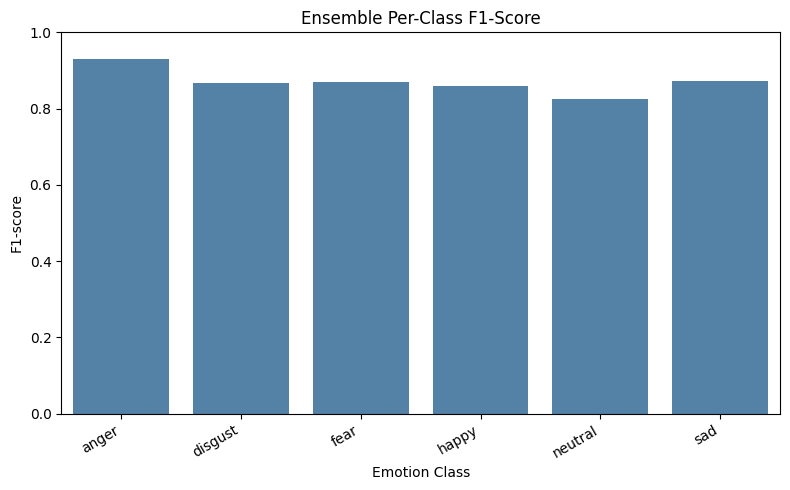

In [13]:
# ============================================================
# Ensemble Per-Class F1-Scores
# ============================================================
class_f1 = [ensemble_report[label]["f1-score"] for label in encoder.classes_]

plt.figure(figsize=(8, 5))
sns.barplot(x=list(encoder.classes_), y=class_f1, color="steelblue")
plt.ylim(0, 1)
plt.ylabel("F1-score")
plt.xlabel("Emotion Class")
plt.title("Ensemble Per-Class F1-Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Final Summary Comparison Table


In [14]:
# ============================================================
# Summary
# ============================================================
print("\n=== Model Comparison Summary ===")
print(f"XGBoost  | Weighted F1: {xgb_f1:.4f} | Cohen's Kappa: {xgb_kappa:.4f}")
print(f"LightGBM | Weighted F1: {lgb_f1:.4f} | Cohen's Kappa: {lgb_kappa:.4f}")
print(f"CatBoost | Weighted F1: {cb_f1:.4f} | Cohen's Kappa: {cb_kappa:.4f}")
print(f"Ensemble | Weighted F1: {ensemble_f1:.4f} | Cohen's Kappa: {ensemble_kappa:.4f}")



=== Model Comparison Summary ===
XGBoost  | Weighted F1: 0.8632 | Cohen's Kappa: 0.8353
LightGBM | Weighted F1: 0.8704 | Cohen's Kappa: 0.8439
CatBoost | Weighted F1: 0.8355 | Cohen's Kappa: 0.8019
Ensemble | Weighted F1: 0.8719 | Cohen's Kappa: 0.8458
